# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
# # Instalação base do projeto + PyTorch com CUDA (Windows / pip)

# %pip install -q --upgrade pip

# # Dependências gerais
# %pip install -q \
#     numpy \
#     pandas \
#     matplotlib \
#     pillow \
#     tqdm \
#     scipy \
#     scikit-learn \
#     jupyter \
#     ipykernel \
#     datasets \
#     accelerate \
#     diffusers \
#     transformers \
#     clean-fid \
#     torchmetrics


#%pip install -q torch-fidelity

# # PyTorch com CUDA (instalar em separado)
# %pip uninstall -y torch torchvision torchaudio
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [2]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    print("GPU não disponível para o PyTorch neste ambiente.")

torch version: 2.6.0+cu124
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
KAGGLE_ROOT = PROJECT_ROOT / "ArtBench-10"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("KAGGLE_ROOT  =", KAGGLE_ROOT)
print("SCRIPTS_DIR  =", SCRIPTS_DIR)

PROJECT_ROOT = c:\git\GAI-Project1
KAGGLE_ROOT  = c:\git\GAI-Project1\ArtBench-10
SCRIPTS_DIR  = c:\git\GAI-Project1\scripts


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='c:\git\GAI-Project1\ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))

Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


In [9]:
# Explicit full train dataset/loader
train_full_ds = HFDatasetTorch(train_hf, transform=transform)
train_full_loader = DataLoader(
    train_full_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Subset train dataset/loader
train_subset_ds = train_ds_from_csv
train_subset_loader = train_loader_from_csv

# Test split loader
test_hf = hf_ds["test"]

test_ds = HFDatasetTorch(test_hf, transform=transform)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Full train dataset length  :", len(train_full_ds))
print("Subset train dataset length:", len(train_subset_ds))
print("Test dataset length        :", len(test_ds))
print("Test batches               :", len(test_loader))

Full train dataset length  : 50000
Subset train dataset length: 10000
Test dataset length        : 10000
Test batches               : 157


## Visualize a sample grid

In [10]:
def denorm(x):
    return x.clamp(-1, 1).add(1).div(2)

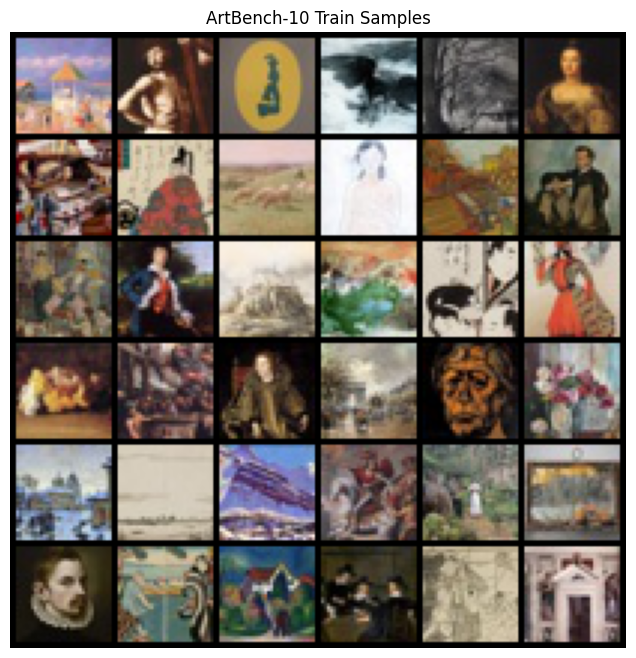

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [11]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(denorm(x), nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np.clip(np_img, 0, 1))
    plt.axis('off')
    plt.title(title)
    plt.show()

    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [12]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(denorm(x[i]), path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(
    train_subset_loader,
    class_names,
    EXPORT_ROOT / "train_subset_20_percent",
    max_images=500,
)

Exported 500 images to: exported_data\train_subset_20_percent\images
Metadata CSV: exported_data\train_subset_20_percent\metadata.csv


# Common Utilities

In [13]:
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

ARTIFACTS_ROOT = Path("artifacts")
CHECKPOINTS_DIR = ARTIFACTS_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACTS_ROOT / "results"
FIGURES_DIR = ARTIFACTS_ROOT / "figures"
SELECTIONS_DIR = RESULTS_DIR / "selections"
FINAL_DIR = RESULTS_DIR / "final"
FINAL_CHECKPOINTS_DIR = CHECKPOINTS_DIR / "final"

for p in [
    ARTIFACTS_ROOT,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    SELECTIONS_DIR,
    FINAL_DIR,
    FINAL_CHECKPOINTS_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)
    
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def show_image_grid(
    images,
    title="Images",
    nrow=8,
    figsize=(8, 8),
    normalize=False,
    save_path=None,
):
    images = images.detach().cpu()

    if normalize:
        images = denorm(images)

    grid = make_grid(images, nrow=nrow, padding=2)
    grid = grid.permute(1, 2, 0)

    plt.figure(figsize=figsize)
    plt.imshow(np.clip(grid.numpy(), 0, 1))
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
        print(f"Figure saved to: {save_path}")

    plt.show()


def plot_training_history(history, title="Training History", save_path=None):
    plt.figure(figsize=(8, 4))
    for key, values in history.items():
        plt.plot(values, label=key)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
        print(f"Figure saved to: {save_path}")

    plt.show()


def save_dataframe(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved dataframe to: {path}")


def save_json(obj, path):
    import json

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

    print(f"Saved json to: {path}")


def save_checkpoint_payload(path: Path, payload: dict):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)
    print(f"Saved checkpoint: {path}")


def save_checkpoint(model, optimizer, epoch, path, history=None, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "history": history,
        "extra": extra,
    }

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_checkpoint(model, optimizer, path, map_location="cpu"):
    checkpoint = torch.load(path, map_location=map_location)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint["optimizer_state_dict"] is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print(f"Checkpoint loaded from: {path}")
    return checkpoint

# ConvVAE

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: [B, 3, 32, 32] -> [B, 256, 4, 4]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Decoder: [B, latent_dim] -> [B, 3, 32, 32]
        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1), # -> 4x4
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 8x8
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 32x32
            nn.Tanh(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), 256, 4, 4)
        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

### VAE Utilities

In [15]:
@torch.no_grad()
def show_vae_reconstructions(
    model,
    dataloader,
    device,
    num_images=16,
    save_dir=None,
    file_prefix="vae",
):
    """
    Show original images and their reconstructions.
    Optionally save both grids to disk.
    """
    model.eval()

    x, y, real_idx = next(iter(dataloader))
    x = x.to(device)

    x_hat, mu, logvar = model(x)

    x = x[:num_images].cpu()
    x_hat = x_hat[:num_images].cpu()

    save_dir = Path(save_dir) if save_dir is not None else None

    original_path = None
    recon_path = None

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        original_path = save_dir / f"{file_prefix}_original_images.png"
        recon_path = save_dir / f"{file_prefix}_reconstructed_images.png"

    print("Original images")
    show_image_grid(
        x,
        title="Original Images",
        nrow=4,
        figsize=(8, 8),
        normalize=True,
        save_path=original_path,
    )

    print("Reconstructed images")
    show_image_grid(
        x_hat,
        title="Reconstructed Images",
        nrow=4,
        figsize=(8, 8),
        normalize=True,
        save_path=recon_path,
    )

    return x, x_hat

@torch.no_grad()
def sample_vae(
    model,
    device,
    num_samples=16,
    seed=None,
    title="VAE Samples",
    save_path=None,
):
    """
    Sample new images from the VAE latent space.
    """
    if seed is not None:
        set_seed(seed)

    model.eval()

    z = torch.randn(num_samples, model.latent_dim, device=device)
    samples = model.decode(z).cpu()

    show_image_grid(
        samples,
        title=title,
        nrow=4,
        figsize=(8, 8),
        normalize=True,
        save_path=save_path,
    )

    return samples


@torch.no_grad()
def interpolate_vae(
    model,
    dataloader,
    device,
    num_steps=8,
    seed=None,
    title="VAE Latent Interpolation",
    save_path=None,
):
    """
    Interpolate between two images in latent space and decode the intermediate points.
    """
    if seed is not None:
        set_seed(seed)

    model.eval()

    x, y, real_idx = next(iter(dataloader))
    x = x.to(device)

    x1 = x[0:1]
    x2 = x[1:2]

    mu1, logvar1 = model.encode(x1)
    mu2, logvar2 = model.encode(x2)

    z1 = model.reparameterise(mu1, logvar1)
    z2 = model.reparameterise(mu2, logvar2)

    alphas = torch.linspace(0.0, 1.0, steps=num_steps, device=device)

    z_interp = []
    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        z_interp.append(z)

    z_interp = torch.cat(z_interp, dim=0)
    x_interp = model.decode(z_interp).cpu()

    show_image_grid(
        x_interp,
        title=title,
        nrow=num_steps,
        figsize=(2 * num_steps, 2),
        normalize=True,
        save_path=save_path,
    )

    return x_interp

### VAE Training Utilities

In [16]:
import torch.optim as optim
from tqdm.auto import tqdm


def train_one_epoch_vae(model, dataloader, optimizer, device, beta=1.0):
    """
    Train the VAE for one epoch.
    """
    model.train()

    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    n_samples = 0

    progress_bar = tqdm(dataloader, desc="Training VAE", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        x_hat, mu, logvar = model(x)
        loss, recon_loss, kl_loss = vae_loss(
            x_hat,
            x,
            mu,
            logvar,
            beta=beta,
        )

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        n_samples += batch_size

        running_loss += loss.item() * batch_size
        running_recon += recon_loss.item() * batch_size
        running_kl += kl_loss.item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "recon": f"{recon_loss.item():.4f}",
            "kl": f"{kl_loss.item():.4f}",
        })

    epoch_loss = running_loss / n_samples
    epoch_recon = running_recon / n_samples
    epoch_kl = running_kl / n_samples

    return epoch_loss, epoch_recon, epoch_kl

### VAE Configurations

In [17]:
vae_configs = [
    {"latent_dim": 32,  "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 64,  "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 0.5, "learning_rate": 1e-3},
    {"latent_dim": 256, "beta": 0.5, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 2.0, "learning_rate": 1e-3},
    {"latent_dim": 128, "beta": 2.0, "learning_rate": 1e-3},

    {"latent_dim": 64,  "beta": 0.5, "learning_rate": 5e-4},
    {"latent_dim": 128, "beta": 0.5, "learning_rate": 5e-4},

    {"latent_dim": 64,  "beta": 1.0, "learning_rate": 5e-4},
    {"latent_dim": 128, "beta": 1.0, "learning_rate": 5e-4},
]

vae_num_epochs_search = 20

print(f"Number of VAE configurations: {len(vae_configs)}")
for i, config in enumerate(vae_configs, start=1):
    print(f"{i:2d}. {config}")

Number of VAE configurations: 12
 1. {'latent_dim': 32, 'beta': 0.5, 'learning_rate': 0.001}
 2. {'latent_dim': 64, 'beta': 0.5, 'learning_rate': 0.001}
 3. {'latent_dim': 128, 'beta': 0.5, 'learning_rate': 0.001}
 4. {'latent_dim': 256, 'beta': 0.5, 'learning_rate': 0.001}
 5. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.001}
 6. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.001}
 7. {'latent_dim': 64, 'beta': 2.0, 'learning_rate': 0.001}
 8. {'latent_dim': 128, 'beta': 2.0, 'learning_rate': 0.001}
 9. {'latent_dim': 64, 'beta': 0.5, 'learning_rate': 0.0005}
10. {'latent_dim': 128, 'beta': 0.5, 'learning_rate': 0.0005}
11. {'latent_dim': 64, 'beta': 1.0, 'learning_rate': 0.0005}
12. {'latent_dim': 128, 'beta': 1.0, 'learning_rate': 0.0005}


## VAE Experiment Runner

In [18]:
def run_vae_experiment(
    config,
    train_loader,
    device,
    num_epochs=20,
    seed=42,
    run_idx=None,
    checkpoint_dir=None,
):
    """
    Train one VAE configuration.

    Returns:
    - trained model
    - training history
    - result dictionary
    """
    set_seed(seed)

    latent_dim = config["latent_dim"]
    beta = config["beta"]
    learning_rate = config["learning_rate"]

    model = ConvVAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
    }

    print(
        f"VAE run={run_idx} | "
        f"latent_dim={latent_dim} | "
        f"beta={beta} | "
        f"lr={learning_rate}"
    )
    print(f"Trainable parameters: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        train_loss, train_recon, train_kl = train_one_epoch_vae(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
            beta=beta,
        )

        history["train_loss"].append(train_loss)
        history["train_recon"].append(train_recon)
        history["train_kl"].append(train_kl)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"loss={train_loss:.4f} | "
            f"recon={train_recon:.4f} | "
            f"kl={train_kl:.4f}"
        )

    result = {
        "family": "vae",
        "run_idx": run_idx,
        "latent_dim": latent_dim,
        "beta": beta,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "num_parameters": count_parameters(model),
        "final_train_loss": history["train_loss"][-1],
        "final_train_recon": history["train_recon"][-1],
        "final_train_kl": history["train_kl"][-1],
        "checkpoint_path": None,
    }

    if checkpoint_dir is not None:
        checkpoint_path = Path(checkpoint_dir) / f"vae_{run_idx}.pt"
        result["checkpoint_path"] = str(checkpoint_path)

        save_checkpoint_payload(
            checkpoint_path,
            {
                "family": "vae",
                "run_idx": run_idx,
                "config": config,
                "seed": seed,
                "num_epochs": num_epochs,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "result": result,
            },
        )

    return model, history, result

## Train VAE Candidate Configurations

In [19]:
device = get_device()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [20]:
vae_models = []
vae_histories = []
vae_results = []

vae_num_epochs_search = 20

for run_idx, config in enumerate(vae_configs, start=1):
    print("\n" + "=" * 80)
    print(f"Starting VAE experiment {run_idx}/{len(vae_configs)}")

    model, history, result = run_vae_experiment(
        config=config,
        train_loader=train_subset_loader,
        device=device,
        num_epochs=vae_num_epochs_search,
        seed=SEED,
        run_idx=run_idx,
        checkpoint_dir=CHECKPOINTS_DIR / "subset" / "vae",
    )

    vae_models.append(model)
    vae_histories.append(history)
    vae_results.append(result)

vae_results_df = pd.DataFrame(vae_results)
save_dataframe(vae_results_df, RESULTS_DIR / "subset" / "vae_training_results.csv")

vae_results_df


Starting VAE experiment 1/12
VAE run=1 | latent_dim=32 | beta=0.5 | lr=0.001
Trainable parameters: 1,318,659


Training VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/20 | loss=404.2488 | recon=390.9342 | kl=26.6291


Training VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 02/20 | loss=260.9828 | recon=243.3459 | kl=35.2737


...

Training VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19/20 | loss=191.6192 | recon=149.7450 | kl=41.8741


Training VAE:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20/20 | loss=191.1512 | recon=148.8919 | kl=42.2593
Saved checkpoint: artifacts\checkpoints\subset\vae\vae_12.pt
Saved dataframe to: artifacts\results\subset\vae_training_results.csv


,family,run_idx,latent_dim,beta,learning_rate,num_epochs,num_parameters,final_train_loss,final_train_recon,final_train_kl,checkpoint_path
0,vae,1,32,0.5,0.0010,20,1318659,165.607204,140.036073,51.142260,artifacts\checkpoints\subset\vae\vae_1.pt
1,vae,2,64,0.5,0.0010,20,1711939,156.474771,123.525889,65.897764,artifacts\checkpoints\subset\vae\vae_2.pt
2,vae,3,128,0.5,0.0010,20,2498499,158.971268,125.984104,65.974328,artifacts\checkpoints\subset\vae\vae_3.pt
3,vae,4,256,0.5,0.0010,20,4071619,163.048111,129.791950,66.512322,artifacts\checkpoints\subset\vae\vae_4.pt
4,vae,5,64,1.0,0.0010,20,1711939,188.094392,145.795167,42.299225,artifacts\checkpoints\subset\vae\vae_5.pt
5,vae,6,128,1.0,0.0010,20,2498499,191.128960,148.924081,42.204879,artifacts\checkpoints\subset\vae\vae_6.pt
6,vae,7,64,2.0,0.0010,20,1711939,227.540989,174.948283,26.296353,artifacts\checkpoints\subset\vae\vae_7.pt
7,vae,8,128,2.0,0.0010,20,2498499,231.725994,180.013917,25.856038,artifacts\checkpoints\subset\vae\vae_8.pt
8,vae,9,64,0.5,0.0005,20,1711939,156.947237,124.517671,64.859131,artifacts\checkpoints\subset\vae\vae_9.pt
9,vae,10,128,0.5,0.0005,20,2498499,158.134208,125.500972,65.266473,artifacts\checkpoints\subset\vae\vae_10.pt


## DCGAN Model

In [21]:
def weights_init(module):
    """
    Initialise convolutional and batch normalisation layers
    following the standard DCGAN recipe.
    """
    classname = module.__class__.__name__

    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)

    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, channels=3):
        super().__init__()
        self.latent_dim = latent_dim

        self.main = nn.Sequential(
            # Input: [B, latent_dim, 1, 1]
            nn.ConvTranspose2d(latent_dim, ngf * 4, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # State: [B, ngf*4, 4, 4]
            nn.ConvTranspose2d(ngf * 4, ngf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # State: [B, ngf*2, 8, 8]
            nn.ConvTranspose2d(ngf * 2, ngf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # State: [B, ngf, 16, 16]
            nn.ConvTranspose2d(ngf, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
            # Output: [B, 3, 32, 32]
        )

    def forward(self, z):
        return self.main(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64, channels=3):
        super().__init__()

        self.main = nn.Sequential(
            # Input: [B, 3, 32, 32]
            nn.Conv2d(channels, ndf, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf, 16, 16]
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf*2, 8, 8]
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # State: [B, ndf*4, 4, 4]
            nn.Conv2d(ndf * 4, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
            # Output: [B, 1, 1, 1]
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)

## DCGAN Utilities

In [22]:
@torch.no_grad()
def sample_dcgan(
    generator,
    fixed_noise,
    title="DCGAN Samples",
    save_path=None,
):
    """
    Generate and display images from a fixed latent batch.
    """
    generator.eval()
    fake_images = generator(fixed_noise).cpu()

    show_image_grid(
        fake_images,
        title=title,
        nrow=4,
        figsize=(8, 8),
        normalize=True,
        save_path=save_path,
    )

    return fake_images


def train_one_epoch_dcgan(
    generator,
    discriminator,
    dataloader,
    optimiser_g,
    optimiser_d,
    criterion,
    device,
    latent_dim=100,
):
    """
    Train DCGAN for one epoch.
    """
    generator.train()
    discriminator.train()

    running_d_loss = 0.0
    running_g_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(dataloader, desc="Training DCGAN", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device, non_blocking=True)

        batch_size = x.size(0)
        real_targets = torch.ones(batch_size, 1, device=device)
        fake_targets = torch.zeros(batch_size, 1, device=device)

        optimiser_d.zero_grad(set_to_none=True)

        real_output = discriminator(x)
        d_loss_real = criterion(real_output, real_targets)

        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_targets)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimiser_d.step()

        optimiser_g.zero_grad(set_to_none=True)

        fake_output = discriminator(fake_images)
        g_loss = criterion(fake_output, real_targets)

        g_loss.backward()
        optimiser_g.step()

        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()
        n_batches += 1

        progress_bar.set_postfix({
            "d_loss": f"{d_loss.item():.4f}",
            "g_loss": f"{g_loss.item():.4f}",
        })

    epoch_d_loss = running_d_loss / n_batches
    epoch_g_loss = running_g_loss / n_batches

    return epoch_d_loss, epoch_g_loss

## DCGAN Candidate Configurations

In [23]:
dcgan_configs = [
    {"latent_dim": 64,  "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 100, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 128, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},

    {"latent_dim": 64,  "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
    {"latent_dim": 100, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
    {"latent_dim": 128, "learning_rate": 2e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},

    {"latent_dim": 100, "learning_rate": 1e-4, "beta1": 0.5, "ngf": 32, "ndf": 32},
    {"latent_dim": 100, "learning_rate": 1e-4, "beta1": 0.5, "ngf": 64, "ndf": 64},
]

dcgan_num_epochs_search = 30

print(f"Number of DCGAN configurations: {len(dcgan_configs)}")
for i, config in enumerate(dcgan_configs, start=1):
    print(f"{i:2d}. {config}")

Number of DCGAN configurations: 8
 1. {'latent_dim': 64, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 2. {'latent_dim': 100, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 3. {'latent_dim': 128, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 4. {'latent_dim': 64, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 5. {'latent_dim': 100, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 6. {'latent_dim': 128, 'learning_rate': 0.0002, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}
 7. {'latent_dim': 100, 'learning_rate': 0.0001, 'beta1': 0.5, 'ngf': 32, 'ndf': 32}
 8. {'latent_dim': 100, 'learning_rate': 0.0001, 'beta1': 0.5, 'ngf': 64, 'ndf': 64}


## DCGAN Experiment Runner

In [24]:
def run_dcgan_experiment(
    config,
    train_loader,
    device,
    num_epochs=15,
    seed=42,
    run_idx=None,
    checkpoint_dir=None,
):
    """
    Train one DCGAN configuration.

    Returns:
    - trained generator
    - trained discriminator
    - training history
    - result dictionary
    """
    set_seed(seed)

    latent_dim = config["latent_dim"]
    learning_rate = config["learning_rate"]
    beta1 = config["beta1"]
    ngf = config["ngf"]
    ndf = config["ndf"]

    generator = Generator(latent_dim=latent_dim, ngf=ngf, channels=3).to(device)
    discriminator = Discriminator(ndf=ndf, channels=3).to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    criterion = nn.BCELoss()

    optimiser_g = optim.Adam(
        generator.parameters(),
        lr=learning_rate,
        betas=(beta1, 0.999),
    )
    optimiser_d = optim.Adam(
        discriminator.parameters(),
        lr=learning_rate,
        betas=(beta1, 0.999),
    )

    fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

    history = {
        "d_loss": [],
        "g_loss": [],
    }

    print(
        f"DCGAN run={run_idx} | "
        f"latent_dim={latent_dim} | "
        f"lr={learning_rate} | "
        f"beta1={beta1} | "
        f"ngf={ngf} | "
        f"ndf={ndf}"
    )
    print(f"Generator parameters    : {count_parameters(generator):,}")
    print(f"Discriminator parameters: {count_parameters(discriminator):,}")

    for epoch in range(num_epochs):
        epoch_d_loss, epoch_g_loss = train_one_epoch_dcgan(
            generator=generator,
            discriminator=discriminator,
            dataloader=train_loader,
            optimiser_g=optimiser_g,
            optimiser_d=optimiser_d,
            criterion=criterion,
            device=device,
            latent_dim=latent_dim,
        )

        history["d_loss"].append(epoch_d_loss)
        history["g_loss"].append(epoch_g_loss)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"d_loss={epoch_d_loss:.4f} | "
            f"g_loss={epoch_g_loss:.4f}"
        )

    result = {
        "family": "dcgan",
        "run_idx": run_idx,
        "latent_dim": latent_dim,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "ngf": ngf,
        "ndf": ndf,
        "num_epochs": num_epochs,
        "generator_parameters": count_parameters(generator),
        "discriminator_parameters": count_parameters(discriminator),
        "final_d_loss": history["d_loss"][-1],
        "final_g_loss": history["g_loss"][-1],
        "checkpoint_path": None,
    }

    if checkpoint_dir is not None:
        checkpoint_path = Path(checkpoint_dir) / f"dcgan_{run_idx}.pt"
        result["checkpoint_path"] = str(checkpoint_path)

        save_checkpoint_payload(
            checkpoint_path,
            {
                "family": "dcgan",
                "run_idx": run_idx,
                "config": config,
                "seed": seed,
                "num_epochs": num_epochs,
                "generator_state_dict": generator.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "optimiser_g_state_dict": optimiser_g.state_dict(),
                "optimiser_d_state_dict": optimiser_d.state_dict(),
                "fixed_noise": fixed_noise.detach().cpu(),
                "history": history,
                "result": result,
            },
        )

    return generator, discriminator, history, result

## Train DCGAN Candidate Configurations

In [25]:
dcgan_generators = []
dcgan_discriminators = []
dcgan_histories = []
dcgan_results = []

for run_idx, config in enumerate(dcgan_configs, start=1):
    print("\n" + "=" * 80)
    print(f"Starting DCGAN experiment {run_idx}/{len(dcgan_configs)}")

    generator, discriminator, history, result = run_dcgan_experiment(
        config=config,
        train_loader=train_subset_loader,
        device=device,
        num_epochs=dcgan_num_epochs_search,
        seed=SEED,
        run_idx=run_idx,
        checkpoint_dir=CHECKPOINTS_DIR / "subset" / "dcgan",
    )

    dcgan_generators.append(generator)
    dcgan_discriminators.append(discriminator)
    dcgan_histories.append(history)
    dcgan_results.append(result)

dcgan_results_df = pd.DataFrame(dcgan_results)
save_dataframe(dcgan_results_df, RESULTS_DIR / "subset" / "dcgan_training_results.csv")

dcgan_results_df


Starting DCGAN experiment 1/8
DCGAN run=1 | latent_dim=64 | lr=0.0002 | beta1=0.5 | ngf=32 | ndf=32
Generator parameters    : 296,896
Discriminator parameters: 167,808


Training DCGAN:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/30 | d_loss=0.4711 | g_loss=3.2162


Training DCGAN:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 02/30 | d_loss=0.5182 | g_loss=3.5036


...

Training DCGAN:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 29/30 | d_loss=0.5307 | g_loss=2.8983


Training DCGAN:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 30/30 | d_loss=0.5346 | g_loss=2.9431
Saved checkpoint: artifacts\checkpoints\subset\dcgan\dcgan_8.pt
Saved dataframe to: artifacts\results\subset\dcgan_training_results.csv


,family,run_idx,latent_dim,learning_rate,beta1,ngf,ndf,num_epochs,generator_parameters,discriminator_parameters,final_d_loss,final_g_loss,checkpoint_path
0,dcgan,1,64,0.0002,0.5,32,32,30,296896,167808,0.691743,2.169438,artifacts\checkpoints\subset\dcgan\dcgan_1.pt
1,dcgan,2,100,0.0002,0.5,32,32,30,370624,167808,0.615287,2.476250,artifacts\checkpoints\subset\dcgan\dcgan_2.pt
2,dcgan,3,128,0.0002,0.5,32,32,30,427968,167808,0.747625,2.647881,artifacts\checkpoints\subset\dcgan\dcgan_3.pt
3,dcgan,4,64,0.0002,0.5,64,64,30,921472,663296,0.558585,2.922726,artifacts\checkpoints\subset\dcgan\dcgan_4.pt
4,dcgan,5,100,0.0002,0.5,64,64,30,1068928,663296,0.684303,2.479066,artifacts\checkpoints\subset\dcgan\dcgan_5.pt
5,dcgan,6,128,0.0002,0.5,64,64,30,1183616,663296,0.620483,3.011963,artifacts\checkpoints\subset\dcgan\dcgan_6.pt
6,dcgan,7,100,0.0001,0.5,32,32,30,370624,167808,0.438971,2.728098,artifacts\checkpoints\subset\dcgan\dcgan_7.pt
7,dcgan,8,100,0.0001,0.5,64,64,30,1068928,663296,0.534595,2.943092,artifacts\checkpoints\subset\dcgan\dcgan_8.pt


## Diffusion Model

In [26]:
from diffusers import DDPMScheduler, UNet2DModel


def build_diffusion_model(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
):
    """
    Build a simple UNet for DDPM-style training on 32x32 RGB images.
    """
    model = UNet2DModel(
        sample_size=sample_size,
        in_channels=in_channels,
        out_channels=out_channels,
        layers_per_block=layers_per_block,
        block_out_channels=block_out_channels,
        down_block_types=(
            "DownBlock2D",
            "AttnDownBlock2D",
            "DownBlock2D",
        ),
        up_block_types=(
            "UpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
        ),
    )
    return model

## Diffusion Utilities

In [27]:
@torch.no_grad()
def sample_diffusion(
    model,
    scheduler,
    device,
    num_samples=16,
    seed=42,
    title="Diffusion Samples",
    num_inference_steps=None,
    save_path=None,
):
    """
    Sample images from a trained diffusion model.
    """
    set_seed(seed)
    model.eval()

    if num_inference_steps is None:
        num_inference_steps = int(scheduler.config.num_train_timesteps)

    try:
        scheduler.set_timesteps(num_inference_steps, device=device)
    except TypeError:
        scheduler.set_timesteps(num_inference_steps)

    x = torch.randn((num_samples, 3, 32, 32), device=device)

    for t in scheduler.timesteps:
        noise_pred = model(x, t).sample
        x = scheduler.step(noise_pred, t, x).prev_sample

    samples = x.detach().cpu()

    show_image_grid(
        samples,
        title=title,
        nrow=4,
        figsize=(8, 8),
        normalize=True,
        save_path=save_path,
    )

    return samples

## Diffusion Training Utilities

In [28]:
def train_one_epoch_diffusion(
    model,
    scheduler,
    dataloader,
    optimizer,
    device,
):
    """
    Train the diffusion model for one epoch using noise prediction.
    """
    model.train()

    running_loss = 0.0
    n_batches = 0

    progress_bar = tqdm(dataloader, desc="Training Diffusion", leave=False)

    for x, y, real_idx in progress_bar:
        x = x.to(device, non_blocking=True)  # images are already in [-1, 1]

        noise = torch.randn_like(x)

        timesteps = torch.randint(
            low=0,
            high=scheduler.config.num_train_timesteps,
            size=(x.size(0),),
            device=device,
        ).long()

        noisy_x = scheduler.add_noise(x, noise, timesteps)
        noise_pred = model(noisy_x, timesteps).sample

        loss = nn.functional.mse_loss(noise_pred, noise)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
        })

    epoch_loss = running_loss / n_batches
    return epoch_loss

## Diffusion Candidate Configurations

In [29]:
diffusion_configs = [
    {"learning_rate": 1e-4, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 2e-4, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 5e-5, "num_train_timesteps": 1000, "block_out_channels": (64, 128, 128)},

    {"learning_rate": 1e-4, "num_train_timesteps": 500, "block_out_channels": (64, 128, 128)},
    {"learning_rate": 2e-4, "num_train_timesteps": 500, "block_out_channels": (64, 128, 128)},

    {"learning_rate": 1e-4, "num_train_timesteps": 1000, "block_out_channels": (32, 64, 128)},
]

diffusion_num_epochs_search = 30

print(f"Number of diffusion configurations: {len(diffusion_configs)}")
for i, config in enumerate(diffusion_configs, start=1):
    print(f"{i:2d}. {config}")

Number of diffusion configurations: 6
 1. {'learning_rate': 0.0001, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 2. {'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 3. {'learning_rate': 5e-05, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
 4. {'learning_rate': 0.0001, 'num_train_timesteps': 500, 'block_out_channels': (64, 128, 128)}
 5. {'learning_rate': 0.0002, 'num_train_timesteps': 500, 'block_out_channels': (64, 128, 128)}
 6. {'learning_rate': 0.0001, 'num_train_timesteps': 1000, 'block_out_channels': (32, 64, 128)}


## Diffusion Experiment Runner

In [30]:
def run_diffusion_experiment(
    config,
    train_loader,
    device,
    num_epochs=10,
    seed=42,
    run_idx=None,
    checkpoint_dir=None,
):
    """
    Train one diffusion configuration.

    Returns:
    - trained model
    - scheduler
    - training history
    - result dictionary
    """
    set_seed(seed)

    learning_rate = config["learning_rate"]
    num_train_timesteps = config["num_train_timesteps"]
    block_out_channels = config["block_out_channels"]

    model = build_diffusion_model(
        sample_size=32,
        in_channels=3,
        out_channels=3,
        layers_per_block=2,
        block_out_channels=block_out_channels,
    ).to(device)

    scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps)

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
    }

    print(
        f"Diffusion run={run_idx} | "
        f"lr={learning_rate} | "
        f"num_train_timesteps={num_train_timesteps} | "
        f"block_out_channels={block_out_channels}"
    )
    print(f"Trainable parameters: {count_parameters(model):,}")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch_diffusion(
            model=model,
            scheduler=scheduler,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
        )

        history["train_loss"].append(train_loss)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"loss={train_loss:.4f}"
        )

    result = {
        "family": "diffusion",
        "run_idx": run_idx,
        "learning_rate": learning_rate,
        "num_train_timesteps": num_train_timesteps,
        "block_out_channels": str(block_out_channels),
        "num_epochs": num_epochs,
        "num_parameters": count_parameters(model),
        "final_train_loss": history["train_loss"][-1],
        "checkpoint_path": None,
    }

    if checkpoint_dir is not None:
        checkpoint_path = Path(checkpoint_dir) / f"diffusion_{run_idx}.pt"
        result["checkpoint_path"] = str(checkpoint_path)

        save_checkpoint_payload(
            checkpoint_path,
            {
                "family": "diffusion",
                "run_idx": run_idx,
                "config": config,
                "seed": seed,
                "num_epochs": num_epochs,
                "model_state_dict": model.state_dict(),
                "scheduler_config": scheduler.config,
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "result": result,
            },
        )

    return model, scheduler, history, result

## Train Diffusion Candidate Configurations

In [31]:
diffusion_models = []
diffusion_schedulers = []
diffusion_histories = []
diffusion_results = []

for run_idx, config in enumerate(diffusion_configs, start=1):
    print("\n" + "=" * 80)
    print(f"Starting diffusion experiment {run_idx}/{len(diffusion_configs)}")

    model, scheduler, history, result = run_diffusion_experiment(
        config=config,
        train_loader=train_subset_loader,
        device=device,
        num_epochs=diffusion_num_epochs_search,
        seed=SEED,
        run_idx=run_idx,
        checkpoint_dir=CHECKPOINTS_DIR / "subset" / "diffusion",
    )

    diffusion_models.append(model)
    diffusion_schedulers.append(scheduler)
    diffusion_histories.append(history)
    diffusion_results.append(result)

diffusion_results_df = pd.DataFrame(diffusion_results)
save_dataframe(diffusion_results_df, RESULTS_DIR / "subset" / "diffusion_training_results.csv")

diffusion_results_df


Starting diffusion experiment 1/6
Diffusion run=1 | lr=0.0001 | num_train_timesteps=1000 | block_out_channels=(64, 128, 128)
Trainable parameters: 6,472,195


Training Diffusion:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/30 | loss=0.1761


Training Diffusion:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 02/30 | loss=0.0667


...

Training Diffusion:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 29/30 | loss=0.0405


Training Diffusion:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 30/30 | loss=0.0395
Saved checkpoint: artifacts\checkpoints\subset\diffusion\diffusion_6.pt
Saved dataframe to: artifacts\results\subset\diffusion_training_results.csv


,family,run_idx,learning_rate,num_train_timesteps,block_out_channels,num_epochs,num_parameters,final_train_loss,checkpoint_path
0,diffusion,1,0.00010,1000,"(64, 128, 128)",30,6472195,0.035825,artifacts\checkpoints\subset\diffusion\diffusi...
1,diffusion,2,0.00020,1000,"(64, 128, 128)",30,6472195,0.034892,artifacts\checkpoints\subset\diffusion\diffusi...
2,diffusion,3,0.00005,1000,"(64, 128, 128)",30,6472195,0.037753,artifacts\checkpoints\subset\diffusion\diffusi...
3,diffusion,4,0.00010,500,"(64, 128, 128)",30,6472195,0.049912,artifacts\checkpoints\subset\diffusion\diffusi...
4,diffusion,5,0.00020,500,"(64, 128, 128)",30,6472195,0.048714,artifacts\checkpoints\subset\diffusion\diffusi...
5,diffusion,6,0.00010,1000,"(32, 64, 128)",30,3692867,0.039533,artifacts\checkpoints\subset\diffusion\diffusi...


## Save candidate configuration mapping

In [32]:
vae_config_map_df = vae_results_df.copy()
vae_config_map_df["family"] = "vae"

dcgan_config_map_df = dcgan_results_df.copy()
dcgan_config_map_df["family"] = "dcgan"

diffusion_config_map_df = diffusion_results_df.copy()
diffusion_config_map_df["family"] = "diffusion"

all_candidate_configs_df = pd.concat(
    [
        vae_config_map_df,
        dcgan_config_map_df,
        diffusion_config_map_df,
    ],
    ignore_index=True,
    sort=False,
)

save_dataframe(
    all_candidate_configs_df,
    RESULTS_DIR / "subset" / "all_candidate_configs.csv",
)

print("\nCandidate configuration map:")
display(all_candidate_configs_df)

Saved dataframe to: artifacts\results\subset\all_candidate_configs.csv

Candidate configuration map:


,family,run_idx,latent_dim,beta,learning_rate,num_epochs,num_parameters,final_train_loss,final_train_recon,final_train_kl,checkpoint_path,beta1,ngf,ndf,generator_parameters,discriminator_parameters,final_d_loss,final_g_loss,num_train_timesteps,block_out_channels
0,vae,1,32.0,0.5,0.00100,20,1318659.0,165.607204,140.036073,51.142260,artifacts\checkpoints\subset\vae\vae_1.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vae,2,64.0,0.5,0.00100,20,1711939.0,156.474771,123.525889,65.897764,artifacts\checkpoints\subset\vae\vae_2.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,vae,3,128.0,0.5,0.00100,20,2498499.0,158.971268,125.984104,65.974328,artifacts\checkpoints\subset\vae\vae_3.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,vae,4,256.0,0.5,0.00100,20,4071619.0,163.048111,129.791950,66.512322,artifacts\checkpoints\subset\vae\vae_4.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,vae,5,64.0,1.0,0.00100,20,1711939.0,188.094392,145.795167,42.299225,artifacts\checkpoints\subset\vae\vae_5.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,vae,6,128.0,1.0,0.00100,20,2498499.0,191.128960,148.924081,42.204879,artifacts\checkpoints\subset\vae\vae_6.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,vae,7,64.0,2.0,0.00100,20,1711939.0,227.540989,174.948283,26.296353,artifacts\checkpoints\subset\vae\vae_7.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,vae,8,128.0,2.0,0.00100,20,2498499.0,231.725994,180.013917,25.856038,artifacts\checkpoints\subset\vae\vae_8.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,vae,9,64.0,0.5,0.00050,20,1711939.0,156.947237,124.517671,64.859131,artifacts\checkpoints\subset\vae\vae_9.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,vae,10,128.0,0.5,0.00050,20,2498499.0,158.134208,125.500972,65.266473,artifacts\checkpoints\subset\vae\vae_10.pt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Evaluation utilities

In [33]:
import ast
from typing import Dict, Any

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def parse_block_out_channels(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, str):
        return tuple(ast.literal_eval(value))
    return tuple(value)


def row_to_vae_config(row) -> Dict[str, Any]:
    return {
        "latent_dim": int(row["latent_dim"]),
        "beta": float(row["beta"]),
        "learning_rate": float(row["learning_rate"]),
    }


def row_to_dcgan_config(row) -> Dict[str, Any]:
    return {
        "latent_dim": int(row["latent_dim"]),
        "learning_rate": float(row["learning_rate"]),
        "beta1": float(row["beta1"]),
        "ngf": int(row["ngf"]),
        "ndf": int(row["ndf"]),
    }


def row_to_diffusion_config(row) -> Dict[str, Any]:
    return {
        "learning_rate": float(row["learning_rate"]),
        "num_train_timesteps": int(row["num_train_timesteps"]),
        "block_out_channels": parse_block_out_channels(row["block_out_channels"]),
    }


def sample_real_images(hf_split, transform, num_images=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(hf_split)
    assert num_images <= n, f"Requested {num_images}, but split only has {n} images."

    indices = rng.choice(n, size=num_images, replace=False)
    xs = []
    for idx in indices:
        ex = hf_split[int(idx)]
        x = transform(ex["image"])
        xs.append(denorm(x).clamp(0, 1))
    return torch.stack(xs, dim=0)


@torch.no_grad()
def generate_vae_images(model, device, latent_dim, num_images=5000, batch_size=64, seed=42):
    set_seed(seed)
    model.eval()
    out = []

    remaining = num_images
    while remaining > 0:
        b = min(batch_size, remaining)
        z = torch.randn(b, latent_dim, device=device)
        fake = model.decode(z)
        fake = denorm(fake).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


@torch.no_grad()
def generate_dcgan_images(generator, device, latent_dim, num_images=5000, batch_size=64, seed=42):
    set_seed(seed)
    generator.eval()
    out = []

    remaining = num_images
    while remaining > 0:
        b = min(batch_size, remaining)
        z = torch.randn(b, latent_dim, 1, 1, device=device)
        fake = generator(z)
        fake = denorm(fake).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


@torch.no_grad()
def generate_diffusion_images(model, scheduler, device, num_images=5000, batch_size=32, seed=42, num_inference_steps=None):
    set_seed(seed)
    model.eval()

    if num_inference_steps is None:
        num_inference_steps = int(scheduler.config.num_train_timesteps)

    try:
        scheduler.set_timesteps(num_inference_steps, device=device)
    except TypeError:
        scheduler.set_timesteps(num_inference_steps)

    out = []
    remaining = num_images

    while remaining > 0:
        b = min(batch_size, remaining)
        x = torch.randn((b, 3, 32, 32), device=device)

        for t in scheduler.timesteps:
            noise_pred = model(x, t).sample
            x = scheduler.step(noise_pred, t, x).prev_sample

        fake = denorm(x).clamp(0, 1).cpu()
        out.append(fake)
        remaining -= b

    return torch.cat(out, dim=0)


def to_uint8_for_metrics(imgs: torch.Tensor) -> torch.Tensor:
    imgs = imgs.clamp(0, 1)
    imgs = (imgs * 255.0).round().to(torch.uint8)
    return imgs


def batched_update_metric(metric, imgs, real: bool, batch_size=64, device=None):
    for i in range(0, imgs.size(0), batch_size):
        batch = imgs[i:i + batch_size].to(device)
        metric.update(batch, real=real)


def compute_fid_kid(real_imgs, fake_imgs, device, batch_size=64, kid_subsets=50, kid_subset_size=100):
    real_uint8 = to_uint8_for_metrics(real_imgs)
    fake_uint8 = to_uint8_for_metrics(fake_imgs)

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid_metric = KernelInceptionDistance(
        feature=2048,
        subsets=kid_subsets,
        subset_size=kid_subset_size,
        normalize=False,
    ).to(device)

    batched_update_metric(fid_metric, real_uint8, real=True, batch_size=batch_size, device=device)
    batched_update_metric(fid_metric, fake_uint8, real=False, batch_size=batch_size, device=device)

    batched_update_metric(kid_metric, real_uint8, real=True, batch_size=batch_size, device=device)
    batched_update_metric(kid_metric, fake_uint8, real=False, batch_size=batch_size, device=device)

    fid_value = float(fid_metric.compute().detach().cpu().item())
    kid_mean, kid_std = kid_metric.compute()

    return {
        "fid": fid_value,
        "kid_mean": float(kid_mean.detach().cpu().item()),
        "kid_std": float(kid_std.detach().cpu().item()),
    }

## Evaluate VAE Configurations with FID / KID

In [35]:
from tqdm.auto import tqdm
import time

DEV_EVAL_SEEDS = list(range(10))
NUM_EVAL_IMAGES = 5000
EVAL_BATCH_SIZE = 64
KID_SUBSETS = 50
KID_SUBSET_SIZE = 100

vae_eval_rows = []

total_steps = len(vae_results_df) * len(DEV_EVAL_SEEDS)

with tqdm(total=total_steps, desc="Evaluating VAE runs") as pbar:
    for _, row in vae_results_df.iterrows():
        run_idx = int(row["run_idx"]) - 1
        model = vae_models[run_idx]

        for eval_seed in DEV_EVAL_SEEDS:
            start = time.time()

            pbar.set_description(
                f"VAE run {int(row['run_idx'])} | seed {eval_seed}"
            )

            real_imgs = sample_real_images(
                test_hf,
                transform=transform,
                num_images=NUM_EVAL_IMAGES,
                seed=eval_seed,
            )

            fake_imgs = generate_vae_images(
                model,
                device=device,
                latent_dim=int(row["latent_dim"]),
                num_images=NUM_EVAL_IMAGES,
                batch_size=EVAL_BATCH_SIZE,
                seed=eval_seed,
            )

            scores = compute_fid_kid(
                real_imgs,
                fake_imgs,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
                kid_subsets=KID_SUBSETS,
                kid_subset_size=KID_SUBSET_SIZE,
            )

            vae_eval_rows.append({
                "family": "vae",
                "run_idx": int(row["run_idx"]),
                "eval_seed": eval_seed,
                **scores,
            })

            elapsed = time.time() - start

            pbar.set_postfix({
                "fid": round(scores.get("fid", float("nan")), 2),
                "kid": round(scores.get("kid_mean", float("nan")), 5),
                "sec": round(elapsed, 1),
            })

            pbar.update(1)

vae_eval_df = pd.DataFrame(vae_eval_rows)
vae_eval_df

Evaluating VAE runs:   0%|          | 0/120 [00:00<?, ?it/s]

c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,family,run_idx,eval_seed,fid,kid_mean,kid_std
0,vae,1,0,229.953384,0.217387,0.009793
1,vae,1,1,228.584717,0.215875,0.007616
2,vae,1,2,228.336716,0.214480,0.008091
3,vae,1,3,229.094223,0.216572,0.010215
4,vae,1,4,231.441269,0.216496,0.009414
...,...,...,...,...,...,...
115,vae,12,5,283.612823,0.302254,0.014448
116,vae,12,6,280.540649,0.297634,0.012176
117,vae,12,7,282.912354,0.301441,0.009222
118,vae,12,8,282.210632,0.302762,0.013825


In [38]:
save_dataframe(vae_eval_df, SELECTIONS_DIR / "vae_eval_per_seed.csv")

Saved dataframe to: artifacts\results\selections\vae_eval_per_seed.csv


## Evaluate DCGAN Configurations with FID / KID

In [36]:
dcgan_eval_rows = []

total_steps = len(dcgan_results_df) * len(DEV_EVAL_SEEDS)

with tqdm(total=total_steps, desc="Evaluating DCGAN runs") as pbar:
    for _, row in dcgan_results_df.iterrows():
        run_idx = int(row["run_idx"]) - 1
        generator = dcgan_generators[run_idx]

        for eval_seed in DEV_EVAL_SEEDS:
            start = time.time()

            pbar.set_description(
                f"DCGAN run {int(row['run_idx'])} | seed {eval_seed}"
            )

            real_imgs = sample_real_images(
                test_hf,
                transform=transform,
                num_images=NUM_EVAL_IMAGES,
                seed=eval_seed,
            )

            fake_imgs = generate_dcgan_images(
                generator,
                device=device,
                latent_dim=int(row["latent_dim"]),
                num_images=NUM_EVAL_IMAGES,
                batch_size=EVAL_BATCH_SIZE,
                seed=eval_seed,
            )

            scores = compute_fid_kid(
                real_imgs,
                fake_imgs,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
                kid_subsets=KID_SUBSETS,
                kid_subset_size=KID_SUBSET_SIZE,
            )

            dcgan_eval_rows.append({
                "family": "dcgan",
                "run_idx": int(row["run_idx"]),
                "eval_seed": eval_seed,
                **scores,
            })

            elapsed = time.time() - start

            pbar.set_postfix({
                "fid": round(scores.get("fid", float("nan")), 2),
                "kid": round(scores.get("kid_mean", float("nan")), 5),
                "sec": round(elapsed, 1),
            })

            pbar.update(1)

dcgan_eval_df = pd.DataFrame(dcgan_eval_rows)
dcgan_eval_df

Evaluating DCGAN runs:   0%|          | 0/80 [00:00<?, ?it/s]

c:\git\GAI-Project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,family,run_idx,eval_seed,fid,kid_mean,kid_std
0,dcgan,1,0,101.066559,0.077058,0.007808
1,dcgan,1,1,100.528625,0.074126,0.005969
2,dcgan,1,2,100.318726,0.075875,0.007669
3,dcgan,1,3,100.252243,0.077450,0.008122
4,dcgan,1,4,101.241943,0.076182,0.007493
...,...,...,...,...,...,...
75,dcgan,8,5,107.030945,0.082536,0.007145
76,dcgan,8,6,106.222786,0.083907,0.008108
77,dcgan,8,7,107.932610,0.085502,0.007152
78,dcgan,8,8,107.602676,0.085158,0.009029


In [39]:
save_dataframe(dcgan_eval_df, SELECTIONS_DIR / "dcgan_eval_per_seed.csv")

Saved dataframe to: artifacts\results\selections\dcgan_eval_per_seed.csv


## Evaluate Diffusion Configurations with FID / KID

In [ ]:
diffusion_eval_rows = []

total_steps = len(diffusion_results_df) * len(DEV_EVAL_SEEDS)

with tqdm(total=total_steps, desc="Evaluating diffusion runs") as pbar:
    for _, row in diffusion_results_df.iterrows():
        run_idx = int(row["run_idx"]) - 1
        model = diffusion_models[run_idx]
        scheduler = diffusion_schedulers[run_idx]

        for eval_seed in DEV_EVAL_SEEDS:
            start = time.time()

            pbar.set_description(
                f"Diffusion run {int(row['run_idx'])} | seed {eval_seed}"
            )

            real_imgs = sample_real_images(
                test_hf,
                transform=transform,
                num_images=NUM_EVAL_IMAGES,
                seed=eval_seed,
            )

            fake_imgs = generate_diffusion_images(
                model,
                scheduler,
                device=device,
                num_images=NUM_EVAL_IMAGES,
                batch_size=32,
                seed=eval_seed,
                num_inference_steps=int(row["num_train_timesteps"]),
            )

            scores = compute_fid_kid(
                real_imgs,
                fake_imgs,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
                kid_subsets=KID_SUBSETS,
                kid_subset_size=KID_SUBSET_SIZE,
            )

            diffusion_eval_rows.append({
                "family": "diffusion",
                "run_idx": int(row["run_idx"]),
                "eval_seed": eval_seed,
                **scores,
            })

            elapsed = time.time() - start

            pbar.set_postfix({
                "fid": round(scores.get("fid", float("nan")), 2),
                "kid": round(scores.get("kid_mean", float("nan")), 5),
                "sec": round(elapsed, 1),
            })

            pbar.update(1)

diffusion_eval_df = pd.DataFrame(diffusion_eval_rows)
diffusion_eval_df

## Diffusion Evaluation Results

The following table reports the FID and KID scores obtained for each diffusion configuration on the 20% training subset.  
Each configuration was evaluated using 10 different evaluation seeds, with 5,000 generated images per seed.

| Family | Run idx | Eval seed | FID | KID mean | KID std |
|---|---:|---:|---:|---:|---:|
| diffusion | 1 | 0 | 117.968445 | 0.109899 | 0.011467 |
| diffusion | 1 | 1 | 118.484550 | 0.107545 | 0.011430 |
| diffusion | 1 | 2 | 119.374413 | 0.108736 | 0.013212 |
| diffusion | 1 | 3 | 116.830803 | 0.108715 | 0.012095 |
| diffusion | 1 | 4 | 118.039925 | 0.108544 | 0.012496 |
| diffusion | 1 | 5 | 119.586082 | 0.111126 | 0.014601 |
| diffusion | 1 | 6 | 118.986488 | 0.110983 | 0.012838 |
| diffusion | 1 | 7 | 117.618835 | 0.107823 | 0.011455 |
| diffusion | 1 | 8 | 118.525284 | 0.108483 | 0.013748 |
| diffusion | 1 | 9 | 116.548798 | 0.103015 | 0.013250 |
| diffusion | 2 | 0 | 67.825890 | 0.040403 | 0.007024 |
| diffusion | 2 | 1 | 67.910446 | 0.039154 | 0.005669 |
| diffusion | 2 | 2 | 67.136665 | 0.039147 | 0.005535 |
| diffusion | 2 | 3 | 66.399269 | 0.039830 | 0.007701 |
| diffusion | 2 | 4 | 67.553970 | 0.040082 | 0.006942 |
| diffusion | 2 | 5 | 68.262665 | 0.041506 | 0.007179 |
| diffusion | 2 | 6 | 68.125427 | 0.041209 | 0.006091 |
| diffusion | 2 | 7 | 66.058365 | 0.038812 | 0.006193 |
| diffusion | 2 | 8 | 67.716515 | 0.040105 | 0.007820 |
| diffusion | 2 | 9 | 67.669067 | 0.038234 | 0.006122 |
| diffusion | 3 | 0 | 173.314804 | 0.168221 | 0.015543 |
| diffusion | 3 | 1 | 173.752853 | 0.169121 | 0.014844 |
| diffusion | 3 | 2 | 176.350922 | 0.172191 | 0.019597 |
| diffusion | 3 | 3 | 170.735718 | 0.169654 | 0.017026 |
| diffusion | 3 | 4 | 172.891510 | 0.165810 | 0.015865 |
| diffusion | 3 | 5 | 176.113464 | 0.171448 | 0.020344 |
| diffusion | 3 | 6 | 174.744553 | 0.172020 | 0.015742 |
| diffusion | 3 | 7 | 171.962143 | 0.168784 | 0.015093 |
| diffusion | 3 | 8 | 174.314850 | 0.173130 | 0.019456 |
| diffusion | 3 | 9 | 171.804688 | 0.163183 | 0.018488 |
| diffusion | 4 | 0 | 98.964462 | 0.077519 | 0.009535 |
| diffusion | 4 | 1 | 94.829948 | 0.072620 | 0.008491 |
| diffusion | 4 | 2 | 99.045586 | 0.078070 | 0.008745 |
| diffusion | 4 | 3 | 96.518623 | 0.076608 | 0.008059 |
| diffusion | 4 | 4 | 96.628616 | 0.075336 | 0.008898 |
| diffusion | 4 | 5 | 96.014229 | 0.074738 | 0.008517 |
| diffusion | 4 | 6 | 98.332535 | 0.077003 | 0.009574 |
| diffusion | 4 | 7 | 97.335518 | 0.075812 | 0.008561 |
| diffusion | 4 | 8 | 99.610001 | 0.079976 | 0.009445 |
| diffusion | 4 | 9 | 97.323563 | 0.075060 | 0.008431 |
| diffusion | 5 | 0 | 78.310265 | 0.055456 | 0.006780 |
| diffusion | 5 | 1 | 75.332687 | 0.052444 | 0.006180 |
| diffusion | 5 | 2 | 75.645760 | 0.052542 | 0.005554 |
| diffusion | 5 | 3 | 75.210823 | 0.052294 | 0.005565 |
| diffusion | 5 | 4 | 75.382141 | 0.051652 | 0.006436 |
| diffusion | 5 | 5 | 75.012909 | 0.052666 | 0.005480 |
| diffusion | 5 | 6 | 75.685883 | 0.052275 | 0.005822 |
| diffusion | 5 | 7 | 75.468460 | 0.051070 | 0.006563 |
| diffusion | 5 | 8 | 76.942467 | 0.054147 | 0.006597 |
| diffusion | 5 | 9 | 75.607590 | 0.051044 | 0.005898 |
| diffusion | 6 | 0 | 180.203308 | 0.139952 | 0.011711 |
| diffusion | 6 | 1 | 180.729080 | 0.140394 | 0.012587 |
| diffusion | 6 | 2 | 179.253830 | 0.138309 | 0.010450 |
| diffusion | 6 | 3 | 181.805435 | 0.141677 | 0.011708 |
| diffusion | 6 | 4 | 180.200424 | 0.138835 | 0.009137 |
| diffusion | 6 | 5 | 180.558899 | 0.140515 | 0.011932 |
| diffusion | 6 | 6 | 182.047501 | 0.141183 | 0.009801 |
| diffusion | 6 | 7 | 179.553696 | 0.138060 | 0.010276 |
| diffusion | 6 | 8 | 181.350754 | 0.141935 | 0.011525 |
| diffusion | 6 | 9 | 179.907440 | 0.138190 | 0.011957 |

In [41]:
save_dataframe(diffusion_eval_df, SELECTIONS_DIR / "diffusion_eval_per_seed.csv")

Saved dataframe to: artifacts\results\selections\diffusion_eval_per_seed.csv


## Summarise Configuration Evaluation

In [42]:
def summarise_config_eval(eval_df):
    return (
        eval_df.groupby("run_idx", as_index=False)
        .agg(
            fid_mean=("fid", "mean"),
            fid_std=("fid", "std"),
            kid_mean_mean=("kid_mean", "mean"),
            kid_mean_std=("kid_mean", "std"),
            kid_std_mean=("kid_std", "mean"),
        )
        .sort_values(by=["fid_mean", "kid_mean_mean"], ascending=True)
        .reset_index(drop=True)
    )

vae_config_summary_df = summarise_config_eval(vae_eval_df)
dcgan_config_summary_df = summarise_config_eval(dcgan_eval_df)
diffusion_config_summary_df = summarise_config_eval(diffusion_eval_df)

vae_config_summary_df, dcgan_config_summary_df, diffusion_config_summary_df

save_dataframe(vae_config_summary_df, SELECTIONS_DIR / "vae_config_summary.csv")
save_dataframe(dcgan_config_summary_df, SELECTIONS_DIR / "dcgan_config_summary.csv")
save_dataframe(diffusion_config_summary_df, SELECTIONS_DIR / "diffusion_config_summary.csv")

save_dataframe(vae_eval_df, SELECTIONS_DIR / "vae_eval_per_seed.csv")
save_dataframe(dcgan_eval_df, SELECTIONS_DIR / "dcgan_eval_per_seed.csv")
save_dataframe(diffusion_eval_df, SELECTIONS_DIR / "diffusion_eval_per_seed.csv")

print("\nBest VAE configuration:")
display(vae_config_summary_df.head(1))

print("\nBest DCGAN configuration:")
display(dcgan_config_summary_df.head(1))

print("\nBest Diffusion configuration:")
display(diffusion_config_summary_df.head(1))

Saved dataframe to: artifacts\results\selections\vae_config_summary.csv
Saved dataframe to: artifacts\results\selections\dcgan_config_summary.csv
Saved dataframe to: artifacts\results\selections\diffusion_config_summary.csv
Saved dataframe to: artifacts\results\selections\vae_eval_per_seed.csv
Saved dataframe to: artifacts\results\selections\dcgan_eval_per_seed.csv
Saved dataframe to: artifacts\results\selections\diffusion_eval_per_seed.csv

Best VAE configuration:


,run_idx,fid_mean,fid_std,kid_mean_mean,kid_mean_std,kid_std_mean
0,2,207.576671,0.665836,0.194988,0.001399,0.008111



Best DCGAN configuration:


,run_idx,fid_mean,fid_std,kid_mean_mean,kid_mean_std,kid_std_mean
0,5,92.772581,0.682162,0.070111,0.001532,0.00744



Best Diffusion configuration:


,run_idx,fid_mean,fid_std,kid_mean_mean,kid_mean_std,kid_std_mean
0,2,67.465828,0.725421,0.039848,0.001037,0.006628


## Select Best Configuration per Family

In [43]:
SELECTED_VAE_RUN_IDX = int(vae_config_summary_df.iloc[0]["run_idx"])
SELECTED_DCGAN_RUN_IDX = int(dcgan_config_summary_df.iloc[0]["run_idx"])
SELECTED_DIFFUSION_RUN_IDX = int(diffusion_config_summary_df.iloc[0]["run_idx"])

selected_vae_row = vae_results_df[vae_results_df["run_idx"] == SELECTED_VAE_RUN_IDX].iloc[0]
selected_dcgan_row = dcgan_results_df[dcgan_results_df["run_idx"] == SELECTED_DCGAN_RUN_IDX].iloc[0]
selected_diffusion_row = diffusion_results_df[diffusion_results_df["run_idx"] == SELECTED_DIFFUSION_RUN_IDX].iloc[0]

selected_vae_model = vae_models[SELECTED_VAE_RUN_IDX - 1]
selected_vae_history = vae_histories[SELECTED_VAE_RUN_IDX - 1]

selected_dcgan_generator = dcgan_generators[SELECTED_DCGAN_RUN_IDX - 1]
selected_dcgan_discriminator = dcgan_discriminators[SELECTED_DCGAN_RUN_IDX - 1]
selected_dcgan_history = dcgan_histories[SELECTED_DCGAN_RUN_IDX - 1]

selected_diffusion_model = diffusion_models[SELECTED_DIFFUSION_RUN_IDX - 1]
selected_diffusion_scheduler = diffusion_schedulers[SELECTED_DIFFUSION_RUN_IDX - 1]
selected_diffusion_history = diffusion_histories[SELECTED_DIFFUSION_RUN_IDX - 1]

print("Selected VAE run:", SELECTED_VAE_RUN_IDX)
print("Selected DCGAN run:", SELECTED_DCGAN_RUN_IDX)
print("Selected Diffusion run:", SELECTED_DIFFUSION_RUN_IDX)

selected_configs_df = pd.DataFrame([
    {
        "family": "vae",
        "selected_run_idx": SELECTED_VAE_RUN_IDX,
        "latent_dim": int(selected_vae_row["latent_dim"]),
        "beta": float(selected_vae_row["beta"]),
        "learning_rate": float(selected_vae_row["learning_rate"]),
        "final_train_loss": float(selected_vae_row["final_train_loss"]),
    },
    {
        "family": "dcgan",
        "selected_run_idx": SELECTED_DCGAN_RUN_IDX,
        "latent_dim": int(selected_dcgan_row["latent_dim"]),
        "learning_rate": float(selected_dcgan_row["learning_rate"]),
        "beta1": float(selected_dcgan_row["beta1"]),
        "ngf": int(selected_dcgan_row["ngf"]),
        "ndf": int(selected_dcgan_row["ndf"]),
        "final_d_loss": float(selected_dcgan_row["final_d_loss"]),
        "final_g_loss": float(selected_dcgan_row["final_g_loss"]),
    },
    {
        "family": "diffusion",
        "selected_run_idx": SELECTED_DIFFUSION_RUN_IDX,
        "learning_rate": float(selected_diffusion_row["learning_rate"]),
        "num_train_timesteps": int(selected_diffusion_row["num_train_timesteps"]),
        "block_out_channels": selected_diffusion_row["block_out_channels"],
        "final_train_loss": float(selected_diffusion_row["final_train_loss"]),
    },
])

save_dataframe(selected_configs_df, SELECTIONS_DIR / "selected_configs_per_family.csv")

print("\nSelected best configuration per family:")
display(selected_configs_df)

Selected VAE run: 2
Selected DCGAN run: 5
Selected Diffusion run: 2
Saved dataframe to: artifacts\results\selections\selected_configs_per_family.csv

Selected best configuration per family:


,family,selected_run_idx,latent_dim,beta,learning_rate,final_train_loss,beta1,ngf,ndf,final_d_loss,final_g_loss,num_train_timesteps,block_out_channels
0,vae,2,64.0,0.5,0.0010,156.474771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,dcgan,5,100.0,NaN,0.0002,NaN,0.5,64.0,64.0,0.684303,2.479066,NaN,NaN
2,diffusion,2,NaN,NaN,0.0002,0.034892,NaN,NaN,NaN,NaN,NaN,1000.0,"(64, 128, 128)"


## Qualitative Inspection of Selected Family Representatives

SAVING QUALITATIVE FIGURES FOR SELECTED MODELS

Selected VAE run: 2
Saving VAE figures to: artifacts\figures\selected_models\vae
Figure saved to: artifacts\figures\selected_models\vae\vae_run2_training_history.png


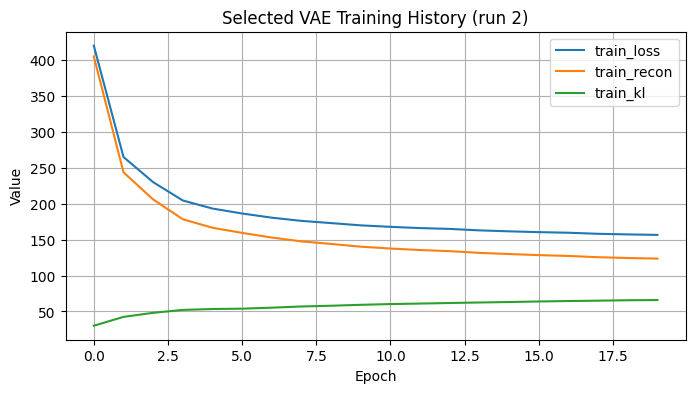

Original images
Figure saved to: artifacts\figures\selected_models\vae\vae_run2_original_images.png


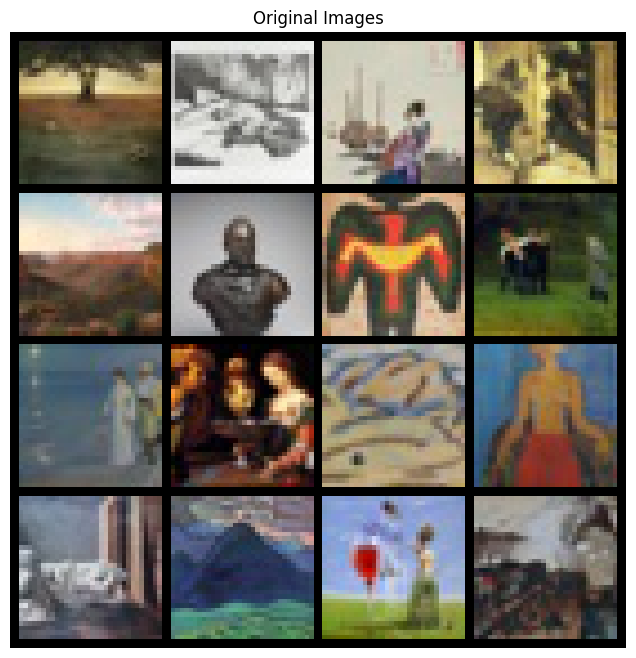

Reconstructed images
Figure saved to: artifacts\figures\selected_models\vae\vae_run2_reconstructed_images.png


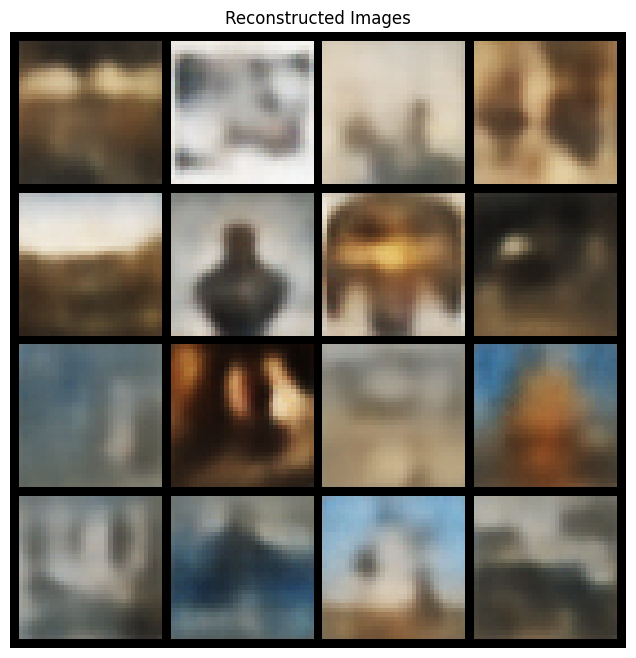

Figure saved to: artifacts\figures\selected_models\vae\vae_run2_samples.png


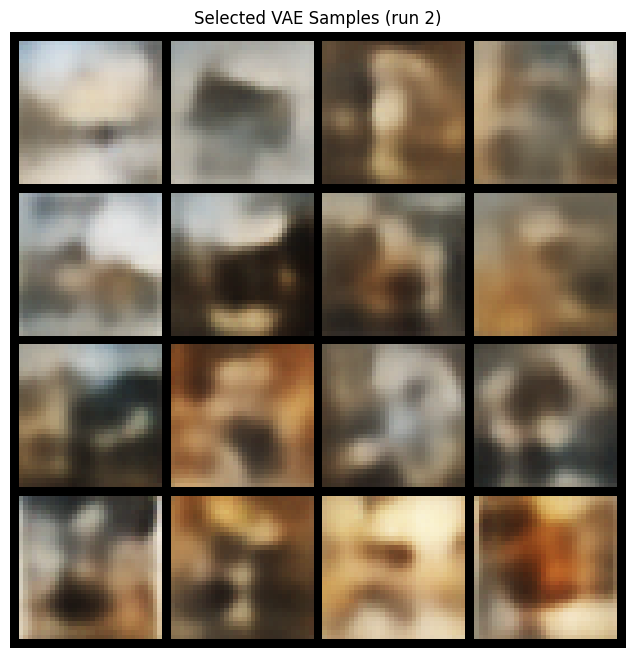

Figure saved to: artifacts\figures\selected_models\vae\vae_run2_interpolation.png


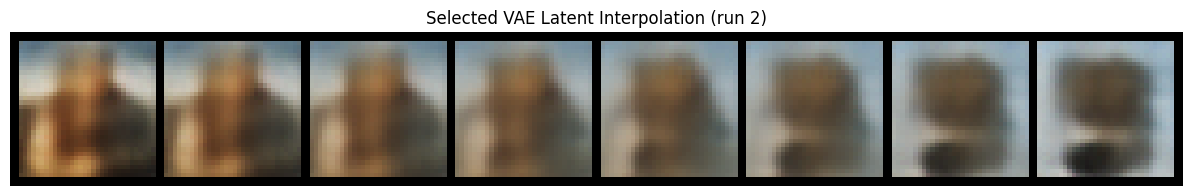


Selected DCGAN run: 5
Saving DCGAN figures to: artifacts\figures\selected_models\dcgan
Figure saved to: artifacts\figures\selected_models\dcgan\dcgan_run5_training_history.png


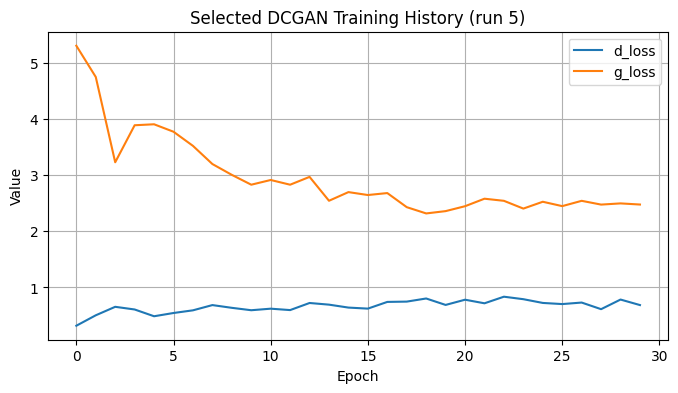

Figure saved to: artifacts\figures\selected_models\dcgan\dcgan_run5_samples.png


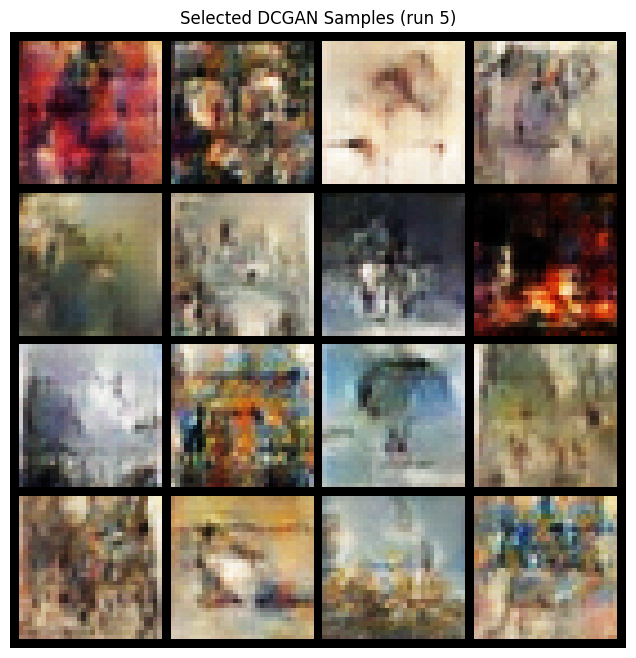


Selected Diffusion run: 2
Saving Diffusion figures to: artifacts\figures\selected_models\diffusion
Figure saved to: artifacts\figures\selected_models\diffusion\diffusion_run2_training_history.png


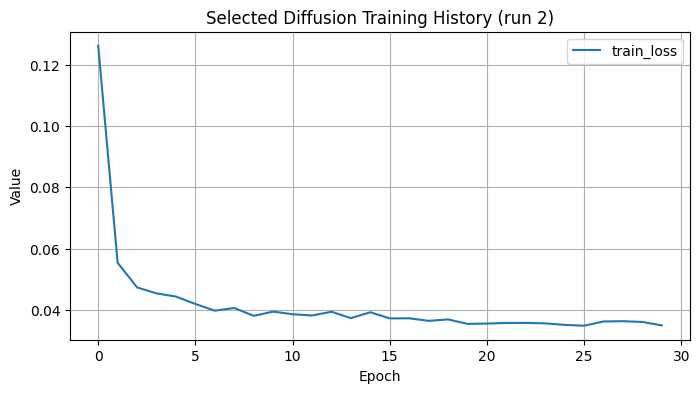

Figure saved to: artifacts\figures\selected_models\diffusion\diffusion_run2_samples.png


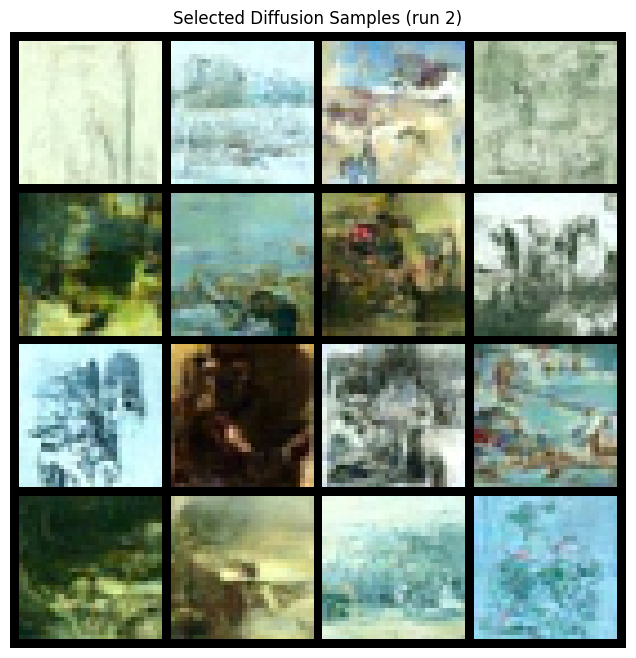


Finished saving selected-model figures.


In [44]:
SELECTED_FIGURES_DIR = FIGURES_DIR / "selected_models"
SELECTED_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
VAE_FIG_DIR = SELECTED_FIGURES_DIR / "vae"
DCGAN_FIG_DIR = SELECTED_FIGURES_DIR / "dcgan"
DIFFUSION_FIG_DIR = SELECTED_FIGURES_DIR / "diffusion"

for p in [VAE_FIG_DIR, DCGAN_FIG_DIR, DIFFUSION_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("SAVING QUALITATIVE FIGURES FOR SELECTED MODELS")
print("=" * 80)


print(f"\nSelected VAE run: {SELECTED_VAE_RUN_IDX}")
print(f"Saving VAE figures to: {VAE_FIG_DIR}")

plot_training_history(
    selected_vae_history,
    title=f"Selected VAE Training History (run {SELECTED_VAE_RUN_IDX})",
    save_path=VAE_FIG_DIR / f"vae_run{SELECTED_VAE_RUN_IDX}_training_history.png",
)

show_vae_reconstructions(
    selected_vae_model,
    train_loader_from_csv,
    device,
    num_images=16,
    save_dir=VAE_FIG_DIR,
    file_prefix=f"vae_run{SELECTED_VAE_RUN_IDX}",
)

_ = sample_vae(
    selected_vae_model,
    device,
    num_samples=16,
    seed=SEED,
    title=f"Selected VAE Samples (run {SELECTED_VAE_RUN_IDX})",
    save_path=VAE_FIG_DIR / f"vae_run{SELECTED_VAE_RUN_IDX}_samples.png",
)

_ = interpolate_vae(
    selected_vae_model,
    train_loader_from_csv,
    device,
    num_steps=8,
    seed=SEED,
    title=f"Selected VAE Latent Interpolation (run {SELECTED_VAE_RUN_IDX})",
    save_path=VAE_FIG_DIR / f"vae_run{SELECTED_VAE_RUN_IDX}_interpolation.png",
)



print(f"\nSelected DCGAN run: {SELECTED_DCGAN_RUN_IDX}")
print(f"Saving DCGAN figures to: {DCGAN_FIG_DIR}")

plot_training_history(
    selected_dcgan_history,
    title=f"Selected DCGAN Training History (run {SELECTED_DCGAN_RUN_IDX})",
    save_path=DCGAN_FIG_DIR / f"dcgan_run{SELECTED_DCGAN_RUN_IDX}_training_history.png",
)

set_seed(SEED)
fixed_noise = torch.randn(16, int(selected_dcgan_row["latent_dim"]), 1, 1, device=device)

_ = sample_dcgan(
    selected_dcgan_generator,
    fixed_noise,
    title=f"Selected DCGAN Samples (run {SELECTED_DCGAN_RUN_IDX})",
    save_path=DCGAN_FIG_DIR / f"dcgan_run{SELECTED_DCGAN_RUN_IDX}_samples.png",
)


print(f"\nSelected Diffusion run: {SELECTED_DIFFUSION_RUN_IDX}")
print(f"Saving Diffusion figures to: {DIFFUSION_FIG_DIR}")

plot_training_history(
    selected_diffusion_history,
    title=f"Selected Diffusion Training History (run {SELECTED_DIFFUSION_RUN_IDX})",
    save_path=DIFFUSION_FIG_DIR / f"diffusion_run{SELECTED_DIFFUSION_RUN_IDX}_training_history.png",
)

_ = sample_diffusion(
    selected_diffusion_model,
    selected_diffusion_scheduler,
    device,
    num_samples=16,
    seed=SEED,
    title=f"Selected Diffusion Samples (run {SELECTED_DIFFUSION_RUN_IDX})",
    num_inference_steps=int(selected_diffusion_row["num_train_timesteps"]),
    save_path=DIFFUSION_FIG_DIR / f"diffusion_run{SELECTED_DIFFUSION_RUN_IDX}_samples.png",
)

print("\nFinished saving selected-model figures.")

## Compare Selected Family Representatives with FID / KID

In [ ]:
NUM_EVAL_IMAGES = 5000
EVAL_SEEDS = list(range(10))
KID_SUBSETS = 50
KID_SUBSET_SIZE = 100
EVAL_BATCH_SIZE = 64

subset_family_eval_rows = []

for eval_seed in EVAL_SEEDS:
    print(f"\n=== Evaluation seed: {eval_seed} ===")

    real_imgs = sample_real_images(
        test_hf,
        transform=transform,
        num_images=NUM_EVAL_IMAGES,
        seed=eval_seed,
    )

    fake_vae = generate_vae_images(
        selected_vae_model,
        device=device,
        latent_dim=int(selected_vae_row["latent_dim"]),
        num_images=NUM_EVAL_IMAGES,
        batch_size=EVAL_BATCH_SIZE,
        seed=eval_seed,
    )
    vae_scores = compute_fid_kid(
        real_imgs,
        fake_vae,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "vae",
        "selected_run_idx": int(selected_vae_row["run_idx"]),
        "eval_seed": eval_seed,
        **vae_scores,
    })
    print("VAE:", vae_scores)

    fake_dcgan = generate_dcgan_images(
        selected_dcgan_generator,
        device=device,
        latent_dim=int(selected_dcgan_row["latent_dim"]),
        num_images=NUM_EVAL_IMAGES,
        batch_size=EVAL_BATCH_SIZE,
        seed=eval_seed,
    )
    dcgan_scores = compute_fid_kid(
        real_imgs,
        fake_dcgan,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "dcgan",
        "selected_run_idx": int(selected_dcgan_row["run_idx"]),
        "eval_seed": eval_seed,
        **dcgan_scores,
    })
    print("DCGAN:", dcgan_scores)

    fake_diffusion = generate_diffusion_images(
        selected_diffusion_model,
        selected_diffusion_scheduler,
        device=device,
        num_images=NUM_EVAL_IMAGES,
        batch_size=32,
        seed=eval_seed,
        num_inference_steps=int(selected_diffusion_row["num_train_timesteps"]),
    )
    diffusion_scores = compute_fid_kid(
        real_imgs,
        fake_diffusion,
        device=device,
        batch_size=EVAL_BATCH_SIZE,
        kid_subsets=KID_SUBSETS,
        kid_subset_size=KID_SUBSET_SIZE,
    )
    subset_family_eval_rows.append({
        "family": "diffusion",
        "selected_run_idx": int(selected_diffusion_row["run_idx"]),
        "eval_seed": eval_seed,
        **diffusion_scores,
    })
    print("Diffusion:", diffusion_scores)

subset_family_eval_df = pd.DataFrame(subset_family_eval_rows)
subset_family_eval_df

## Selected Family Representatives Evaluation

This section reports the per-seed FID and KID evaluation results for the selected representative model from each generative family.

The selected models are:

| Family | Selected run |
|---|---:|
| VAE | 2 |
| DCGAN | 1 |
| Diffusion | 2 |

For each evaluation seed, 5,000 generated images were compared against 5,000 real test images from the ArtBench-10 test split.

| Eval seed | Family | Selected run | FID | KID mean | KID std |
|---:|---|---:|---:|---:|---:|
| 0 | VAE | 2 | 214.170013 | 0.204553 | 0.007834 |
| 0 | DCGAN | 1 | 106.565002 | 0.090747 | 0.009129 |
| 0 | Diffusion | 2 | 67.825890 | 0.040403 | 0.007024 |
| 1 | VAE | 2 | 212.426437 | 0.201309 | 0.007846 |
| 1 | DCGAN | 1 | 105.211327 | 0.086339 | 0.008006 |
| 1 | Diffusion | 2 | 67.910446 | 0.039154 | 0.005669 |
| 2 | VAE | 2 | 212.571579 | 0.201512 | 0.007916 |
| 2 | DCGAN | 1 | 105.007095 | 0.086682 | 0.009466 |
| 2 | Diffusion | 2 | 67.136665 | 0.039147 | 0.005535 |
| 3 | VAE | 2 | 212.753708 | 0.203701 | 0.008764 |
| 3 | DCGAN | 1 | 104.280144 | 0.089180 | 0.008942 |
| 3 | Diffusion | 2 | 66.399269 | 0.039830 | 0.007701 |
| 4 | VAE | 2 | 213.067261 | 0.201669 | 0.007241 |
| 4 | DCGAN | 1 | 105.888710 | 0.086544 | 0.008167 |
| 4 | Diffusion | 2 | 67.553970 | 0.040082 | 0.006942 |
| 5 | VAE | 2 | 212.357300 | 0.200402 | 0.010197 |
| 5 | DCGAN | 1 | 104.940788 | 0.085613 | 0.009320 |
| 5 | Diffusion | 2 | 68.262665 | 0.041506 | 0.007179 |
| 6 | VAE | 2 | 212.406937 | 0.201987 | 0.008330 |
| 6 | DCGAN | 1 | 104.663391 | 0.087689 | 0.009229 |
| 6 | Diffusion | 2 | 68.125427 | 0.041209 | 0.006091 |
| 7 | VAE | 2 | 213.426727 | 0.202685 | 0.006657 |
| 7 | DCGAN | 1 | 104.960930 | 0.085703 | 0.007393 |
| 7 | Diffusion | 2 | 66.058365 | 0.038812 | 0.006193 |
| 8 | VAE | 2 | 212.341614 | 0.202102 | 0.009480 |
| 8 | DCGAN | 1 | 105.197975 | 0.088409 | 0.009047 |
| 8 | Diffusion | 2 | 67.716515 | 0.040105 | 0.007820 |
| 9 | VAE | 2 | 212.968292 | 0.203098 | 0.009215 |
| 9 | DCGAN | 1 | 104.648224 | 0.086117 | 0.009278 |
| 9 | Diffusion | 2 | 67.669067 | 0.038234 | 0.006122 |

## Aggregate Family Comparison

In [47]:
subset_family_summary_df = (
    subset_family_eval_df
    .groupby("family", as_index=False)
    .agg(
        fid_mean=("fid", "mean"),
        fid_std=("fid", "std"),
        kid_mean_mean=("kid_mean", "mean"),
        kid_mean_std=("kid_mean", "std"),
        kid_std_mean=("kid_std", "mean"),
    )
    .sort_values(by=["fid_mean", "kid_mean_mean"], ascending=True)
    .reset_index(drop=True)
)

subset_family_summary_df

save_dataframe(subset_family_eval_df, SELECTIONS_DIR / "selected_family_eval_per_seed.csv")
save_dataframe(subset_family_summary_df, SELECTIONS_DIR / "selected_family_summary.csv")

print("\nCross-family comparison summary:")
display(subset_family_summary_df)

Saved dataframe to: artifacts\results\selections\selected_family_eval_per_seed.csv
Saved dataframe to: artifacts\results\selections\selected_family_summary.csv

Cross-family comparison summary:


,family,fid_mean,fid_std,kid_mean_mean,kid_mean_std,kid_std_mean
0,diffusion,67.465828,0.725421,0.039848,0.001037,0.006628
1,dcgan,105.136359,0.658051,0.087302,0.001682,0.008798
2,vae,212.848987,0.586889,0.202302,0.001227,0.008348


## Select Global Best Family

In [48]:
best_global_family = subset_family_summary_df.iloc[0]["family"]
print("Best global family on subset comparison:", best_global_family)

Best global family on subset comparison: diffusion


## Select Global-Best Configuration

In [49]:
if best_global_family == "vae":
    global_best_config = row_to_vae_config(selected_vae_row)
elif best_global_family == "dcgan":
    global_best_config = row_to_dcgan_config(selected_dcgan_row)
elif best_global_family == "diffusion":
    global_best_config = row_to_diffusion_config(selected_diffusion_row)
else:
    raise ValueError(f"Unknown family: {best_global_family}")

print("Global best family :", best_global_family)
print("Global best config :", global_best_config)

global_best_payload = {
    "best_global_family": best_global_family,
    "global_best_config": global_best_config,
    "selected_vae_run_idx": SELECTED_VAE_RUN_IDX,
    "selected_dcgan_run_idx": SELECTED_DCGAN_RUN_IDX,
    "selected_diffusion_run_idx": SELECTED_DIFFUSION_RUN_IDX,
}

save_json(global_best_payload, SELECTIONS_DIR / "global_best_config.json")

print("\n" + "=" * 80)
print("GLOBAL BEST MODEL SELECTED")
print("=" * 80)
print(f"Family: {best_global_family}")
print(f"Config: {global_best_config}")
print("=" * 80)

Global best family : diffusion
Global best config : {'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}
Saved json to: artifacts\results\selections\global_best_config.json

GLOBAL BEST MODEL SELECTED
Family: diffusion
Config: {'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}


## Full-Dataset Retraining Settings

In [50]:
FULL_NUM_EPOCHS = 30
FULL_TRAIN_SEEDS = list(range(10))
FINAL_NUM_EVAL_IMAGES = 5000
FINAL_EVAL_BATCH_SIZE = 64
FINAL_KID_SUBSETS = 50
FINAL_KID_SUBSET_SIZE = 100

FINAL_BEST_FIGURES_DIR = FIGURES_DIR / "final_best_model"
FINAL_BEST_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Final full-dataset settings:")
print(f"  epochs             : {FULL_NUM_EPOCHS}")
print(f"  train seeds        : {FULL_TRAIN_SEEDS}")
print(f"  eval images        : {FINAL_NUM_EVAL_IMAGES}")
print(f"  final figures dir  : {FINAL_BEST_FIGURES_DIR}")

Final full-dataset settings:
  epochs             : 30
  train seeds        : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  eval images        : 5000
  final figures dir  : artifacts\figures\final_best_model


## Train Selected Family on Full Dataset

In [51]:
def train_selected_family_on_full_dataset(
    family,
    config,
    train_loader,
    device,
    num_epochs=10,
    seed=42,
    checkpoint_dir=None,
):
    if family == "vae":
        model, history, result = run_vae_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
            run_idx=f"final_seed{seed}",
            checkpoint_dir=checkpoint_dir / "vae" if checkpoint_dir is not None else None,
        )
        return {
            "family": family,
            "model": model,
            "history": history,
            "train_result": result,
        }

    if family == "dcgan":
        generator, discriminator, history, result = run_dcgan_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
            run_idx=f"final_seed{seed}",
            checkpoint_dir=checkpoint_dir / "dcgan" if checkpoint_dir is not None else None,
        )
        return {
            "family": family,
            "generator": generator,
            "discriminator": discriminator,
            "history": history,
            "train_result": result,
        }

    if family == "diffusion":
        model, scheduler, history, result = run_diffusion_experiment(
            config=config,
            train_loader=train_loader,
            device=device,
            num_epochs=num_epochs,
            seed=seed,
            run_idx=f"final_seed{seed}",
            checkpoint_dir=checkpoint_dir / "diffusion" if checkpoint_dir is not None else None,
        )
        return {
            "family": family,
            "model": model,
            "scheduler": scheduler,
            "history": history,
            "train_result": result,
        }

    raise ValueError(f"Unknown family: {family}")

## Evaluate Trained Family Model

In [52]:
def evaluate_trained_family_model(trained_spec, hf_test_split, transform, device, eval_seed=42, num_eval_images=5000):
    real_imgs = sample_real_images(
        hf_test_split,
        transform=transform,
        num_images=num_eval_images,
        seed=eval_seed,
    )

    family = trained_spec["family"]

    if family == "vae":
        latent_dim = int(trained_spec["train_result"]["latent_dim"])
        fake_imgs = generate_vae_images(
            trained_spec["model"],
            device=device,
            latent_dim=latent_dim,
            num_images=num_eval_images,
            batch_size=FINAL_EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

    elif family == "dcgan":
        latent_dim = int(trained_spec["train_result"]["latent_dim"])
        fake_imgs = generate_dcgan_images(
            trained_spec["generator"],
            device=device,
            latent_dim=latent_dim,
            num_images=num_eval_images,
            batch_size=FINAL_EVAL_BATCH_SIZE,
            seed=eval_seed,
        )

    elif family == "diffusion":
        num_steps = int(trained_spec["train_result"]["num_train_timesteps"])
        fake_imgs = generate_diffusion_images(
            trained_spec["model"],
            trained_spec["scheduler"],
            device=device,
            num_images=num_eval_images,
            batch_size=32,
            seed=eval_seed,
            num_inference_steps=num_steps,
        )

    else:
        raise ValueError(f"Unknown family: {family}")

    scores = compute_fid_kid(
        real_imgs,
        fake_imgs,
        device=device,
        batch_size=FINAL_EVAL_BATCH_SIZE,
        kid_subsets=FINAL_KID_SUBSETS,
        kid_subset_size=FINAL_KID_SUBSET_SIZE,
    )
    return scores

## Final Full-Dataset Protocol

In [ ]:
final_runs = []

best_final_fid = float("inf")
best_final_seed = None
best_final_trained_spec = None
best_final_scores = None

for seed in FULL_TRAIN_SEEDS:
    print("\n" + "=" * 100)
    print("FINAL FULL-DATASET TRAINING RUN")
    print("=" * 100)
    print(f"Selected family : {best_global_family}")
    print(f"Selected config : {global_best_config}")
    print(f"Seed            : {seed}")
    print(f"Train dataset   : full train split ({len(train_full_ds)} images)")
    print(f"Eval dataset    : test split ({len(test_ds)} images)")
    print("=" * 100)

    trained_spec = train_selected_family_on_full_dataset(
        family=best_global_family,
        config=global_best_config,
        train_loader=train_full_loader,
        device=device,
        num_epochs=FULL_NUM_EPOCHS,
        seed=seed,
        checkpoint_dir=FINAL_CHECKPOINTS_DIR,
    )

    final_scores = evaluate_trained_family_model(
        trained_spec=trained_spec,
        hf_test_split=test_hf,
        transform=transform,
        device=device,
        eval_seed=seed,
        num_eval_images=FINAL_NUM_EVAL_IMAGES,
    )

    row = {
        "family": best_global_family,
        "seed": seed,
        **trained_spec["train_result"],
        **final_scores,
    }
    final_runs.append(row)

    print("Final scores:", final_scores)

    # Keep the best final model in memory, based on lowest FID.
    if final_scores["fid"] < best_final_fid:
        best_final_fid = final_scores["fid"]
        best_final_seed = seed
        best_final_scores = final_scores

        # Move the best model to CPU before storing it,
        # so the next full-dataset run does not keep multiple models on GPU.
        if trained_spec["family"] == "vae":
            trained_spec["model"] = trained_spec["model"].cpu()

        elif trained_spec["family"] == "dcgan":
            trained_spec["generator"] = trained_spec["generator"].cpu()
            trained_spec["discriminator"] = trained_spec["discriminator"].cpu()

        elif trained_spec["family"] == "diffusion":
            trained_spec["model"] = trained_spec["model"].cpu()

        best_final_trained_spec = trained_spec

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\nNEW BEST FINAL MODEL")
        print(f"  family : {best_global_family}")
        print(f"  seed   : {best_final_seed}")
        print(f"  fid    : {best_final_scores['fid']:.4f}")
        print(f"  kid    : {best_final_scores['kid_mean']:.6f}")

final_results_df = pd.DataFrame(final_runs)

print("\n" + "=" * 100)
print("BEST FINAL MODEL AFTER ALL FULL-DATASET RUNS")
print("=" * 100)
print(f"Family : {best_global_family}")
print(f"Seed   : {best_final_seed}")
print(f"FID    : {best_final_scores['fid']:.4f}")
print(f"KID    : {best_final_scores['kid_mean']:.6f} ± {best_final_scores['kid_std']:.6f}")
print(f"Config : {global_best_config}")
print("=" * 100)

final_results_df

**Best final model after all full-dataset runs**

| Field | Value |
|---|---:|
| Family | diffusion |
| Seed | 2 |
| FID | 41.3038 |
| KID | 0.022261 ± 0.003957 |
| Config | `{'learning_rate': 0.0002, 'num_train_timesteps': 1000, 'block_out_channels': (64, 128, 128)}` |

| family | seed | learning_rate | num_train_timesteps | block_out_channels | num_epochs | final_train_loss | fid | kid_mean | kid_std |
|---|---:|---:|---:|---|---:|---:|---:|---:|---:|
| diffusion | 0 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033462 | 63.390812 | 0.045635 | 0.006866 |
| diffusion | 1 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.032659 | 67.025558 | 0.055686 | 0.007775 |
| diffusion | 2 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033135 | 41.303825 | 0.022261 | 0.003957 |
| diffusion | 3 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033076 | 67.135124 | 0.050302 | 0.007603 |
| diffusion | 4 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033278 | 46.627926 | 0.028135 | 0.004896 |
| diffusion | 5 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033452 | 52.718449 | 0.036857 | 0.005311 |
| diffusion | 6 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.032956 | 58.489773 | 0.038660 | 0.006752 |
| diffusion | 7 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033162 | 74.088409 | 0.055765 | 0.007060 |
| diffusion | 8 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033530 | 47.841312 | 0.029470 | 0.005311 |
| diffusion | 9 | 0.0002 | 1000 | (64, 128, 128) | 30 | 0.033073 | 62.689716 | 0.049757 | 0.006513 |

## Final Report Summary

In [55]:
## Final Report Summary
final_summary_df = (
    final_results_df
    .agg({
        "fid": ["mean", "std"],
        "kid_mean": ["mean", "std"],
    })
)

save_dataframe(final_results_df, FINAL_DIR / "final_results_per_seed.csv")
save_dataframe(final_summary_df.reset_index(), FINAL_DIR / "final_results_summary.csv")

best_final_row = final_results_df.sort_values(by=["fid", "kid_mean"], ascending=True).iloc[0]

best_final_model_df = pd.DataFrame([{
    "family": best_global_family,
    "best_seed": int(best_final_seed),
    "fid": float(best_final_scores["fid"]),
    "kid_mean": float(best_final_scores["kid_mean"]),
    "kid_std": float(best_final_scores["kid_std"]),
    "config": str(global_best_config),
    "checkpoint_path": best_final_trained_spec["train_result"].get("checkpoint_path"),
}])

save_dataframe(best_final_model_df, FINAL_DIR / "best_final_model.csv")

best_final_payload = {
    "family": best_global_family,
    "best_seed": int(best_final_seed),
    "scores": best_final_scores,
    "config": global_best_config,
    "checkpoint_path": best_final_trained_spec["train_result"].get("checkpoint_path"),
}

save_json(best_final_payload, FINAL_DIR / "best_final_model.json")

print("Saved final results:")
print(f" - {FINAL_DIR / 'final_results_per_seed.csv'}")
print(f" - {FINAL_DIR / 'final_results_summary.csv'}")
print(f" - {FINAL_DIR / 'best_final_model.csv'}")
print(f" - {FINAL_DIR / 'best_final_model.json'}")

print("\nBest final model:")
display(best_final_model_df)

final_summary_df

Saved dataframe to: artifacts\results\final\final_results_per_seed.csv
Saved dataframe to: artifacts\results\final\final_results_summary.csv
Saved dataframe to: artifacts\results\final\best_final_model.csv
Saved json to: artifacts\results\final\best_final_model.json
Saved final results:
 - artifacts\results\final\final_results_per_seed.csv
 - artifacts\results\final\final_results_summary.csv
 - artifacts\results\final\best_final_model.csv
 - artifacts\results\final\best_final_model.json

Best final model:


,family,best_seed,fid,kid_mean,kid_std,config,checkpoint_path
0,diffusion,2,41.303825,0.022261,0.003957,"{'learning_rate': 0.0002, 'num_train_timesteps...",artifacts\checkpoints\final\diffusion\diffusio...


,fid,kid_mean
mean,58.131091,0.041253
std,10.614720,0.011972
